In [2]:
import pandas as pd 
import numpy as np

#fro ploting 
import matplotlib.pyplot as plt
import seaborn as sns

#for q-q plots
import scipy.stats as stats 

# for dataset loding 
from sklearn.datasets import fetch_california_housing

# for linear regrison 
from sklearn.linear_model import LinearRegression

# for split and siandoriste the datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#fro evaluation regreastion model 
from sklearn.metrics import mean_squared_error



In [4]:
# load data set

X, Y = fetch_california_housing(return_X_y= True, as_frame= True)

X.drop(columns=['Latitude', 'Longitude'], inplace= True)

X.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


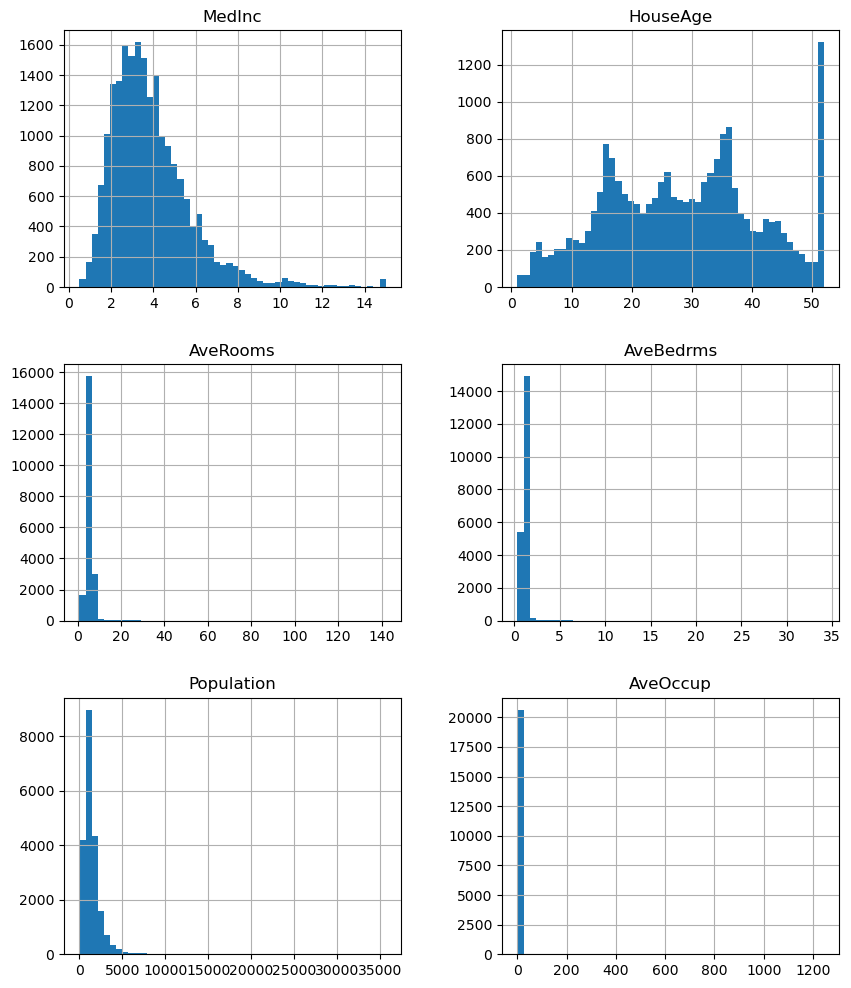

In [12]:
X.hist( bins=50, figsize=(10,12))
plt.show()

In [16]:
# traine and evaluate model 
# first split the data 

X_train, X_test , y_train , y_test =  train_test_split(
    X,
    Y,
    test_size= 0.30, 
    random_state=0
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14448, 6), (6192, 6), (14448,), (6192,))

In [19]:
# scale the features 

scaler = StandardScaler()
scaler.fit(X_train)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
1989,1.9750,52.0,2.800000,0.700000,193.0,4.825000
256,2.2604,43.0,3.671480,1.184116,836.0,3.018051
7887,6.2990,17.0,6.478022,1.087912,1387.0,3.810440
4581,1.7199,17.0,2.518000,1.196000,3051.0,3.051000
1993,2.2206,50.0,4.622754,1.161677,606.0,3.628743


In [25]:
#fit the linear model 
liner = LinearRegression()
liner.fit(scaler.transform(X_train), y_train)

#make prediction on the train set and sclculate the MSE

pred_train = liner.predict(scaler.transform(X_train))
print('train set is ')
mse = mean_squared_error(y_train, pred_train)
print (f'main sqeure erro is: {mse}')

pred_test = liner.predict(scaler.transform(X_test))
mse_test = mean_squared_error(pred_test,y_test)

print(f' MSE fro test: {mse_test}')


train set is 
main sqeure erro is: 0.5987894249515697
 MSE fro test: 0.6525344505004611


In [27]:
# fit the linear regrtion 
lg = LinearRegression()
lg.fit(scaler.transform(X_train), y_train)


pred_y = lg.predict(scaler.transform(X_train))
mse_train = mean_squared_error(y_train, pred_y)

print(f"mse train:{mse_train}")

pred_test_y = lg.predict(scaler.transform(X_test))
mse_test = mean_squared_error(pred_test_y,y_test)

print(f'MSE for test:{mse_test}')

mse train:0.5987894249515697
MSE for test:0.6525344505004611


$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$
$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 }
$$


In [ ]:

"""
What this gives you:
Model MSE/RMSE → how well your model predicts.

Baseline MSE/RMSE → error if you always predicted the mean (no learning).

If your model’s RMSE is much lower than the baseline, that’s a good sign 🚀.
"""

# from sklearn.metrics import mean_squared_error
# import numpy as np

# 1. Model MSE & RMSE
mse_model = mean_squared_error(y_test, pred_test_y)
rmse_model = np.sqrt(mse_model)

# 2. Baseline (predict mean of y_test for all cases)
y_baseline = np.full_like(y_test, y_test.mean(), dtype=float)
mse_baseline = mean_squared_error(y_test, y_baseline)
rmse_baseline = np.sqrt(mse_baseline)

print("Model MSE:", mse_model)
print("Model RMSE:", rmse_model)
print("Baseline MSE:", mse_baseline)
print("Baseline RMSE:", rmse_baseline)


Model MSE: 0.6525344505004611
Model RMSE: 0.8077960451131592
Baseline MSE: 1.3332367964951082
Baseline RMSE: 1.1546587359454343


$$
\text{MSE}_{model} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

$$
\text{RMSE}_{model} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$


$$
\hat{y}_i = \bar{y} \quad \forall i
$$

$$
\text{MSE}_{baseline} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2
$$

$$
\text{RMSE}_{baseline} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2 }
$$

- Model RMSE = 0.808
- Baseline RMSE = 1.155

النموذج يقلل الخطأ بنسبة تقارب:
$$
\frac{1.155 - 0.808}{1.155} \times 100 \approx 30\%
$$


In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

# MSE & RMSE للموديل
mse_model = mean_squared_error(y_test, pred_test_y)
rmse_model = np.sqrt(mse_model)

# Baseline (التنبؤ بالمتوسط فقط)
y_baseline = np.full_like(y_test, y_test.mean(), dtype=float)
mse_baseline = mean_squared_error(y_test, y_baseline)
rmse_baseline = np.sqrt(mse_baseline)

# نسبة التحسن
improvement = (rmse_baseline - rmse_model) / rmse_baseline * 100

print(f"Model MSE: {mse_model:.4f}")
print(f"Model RMSE: {rmse_model:.4f}")
print(f"Baseline MSE: {mse_baseline:.4f}")
print(f"Baseline RMSE: {rmse_baseline:.4f}")
print(f"Improvement over baseline: {improvement:.2f}%")


Model MSE: 0.6525
Model RMSE: 0.8078
Baseline MSE: 1.3332
Baseline RMSE: 1.1547
Improvement over baseline: 30.04%


In [26]:
y_train.mean()

np.float64(2.0682462451550387)

In [30]:
#calcluting the residuals.

residuals_error = y_test - pred_test_y
residuals_error

14740   -0.671811
10101   -0.433458
20566   -0.148244
2670    -1.006485
15709    1.764494
           ...   
19681   -1.012555
12156    0.426857
10211   -0.160086
2445    -0.209008
17914    0.509850
Name: MedHouseVal, Length: 6192, dtype: float64